# Interactive Visualization Notebook

This notebook is the presentation layer of the pipeline. It shows how prepared structures, trajectory frames, PMFs, and timeseries are turned into clear, portfolio-ready figures and interactive widgets.

## Visualization Goals

Good molecular visualization should answer a physical question, not just decorate the result. In this project, the main questions are structural: where is the interface, how does the complex move, and how do free-energy or RMSD summaries connect back to a concrete 3D conformation?

The `py3Dmol` widgets below are intended for exactly that interpretive step.

In [ ]:
# Resolve project root and import visualization modules.
from pathlib import Path
import sys
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DATA_DIR
from src.visualization.viewer_3d import render_structure, render_complex
from src.visualization.plot_pmf import plot_pmf
from src.visualization.plot_timeseries import plot_energy_timeseries, plot_temperature_timeseries, plot_rmsd_timeseries

## Static Structure Widget

If the notebook is trusted in Jupyter, the next cell will return a live `py3Dmol` widget. Interface residues can be highlighted directly in the molecular scene.

In [2]:
prepared_pdb = DATA_DIR / 'pdb' / 'prepared' / 'example_complex.pdb'
# 1BRS Barnase-Barstar complex: known interface residues
# Barnase (chain A): Lys27, Arg59, Arg83, Arg87
# Barstar (chain D): Asp35, Asp39, Glu76, Glu80
interface_residues = [27, 59, 83, 87, 35, 39, 76, 80]
complex_view = render_complex(prepared_pdb, highlight_interface_residues=interface_residues, style='cartoon')
complex_view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
trajectory_path = DATA_DIR / 'trajectories' / 'production' / 'demo' / 'production.dcd'
topology_path = DATA_DIR / 'pdb' / 'prepared' / 'example_solvated.pdb'

# Load only when the trajectory exists locally.
# trajectory = load_trajectory(trajectory_path, topology_path, stride=10)
# frame_view = render_trajectory_frame(trajectory, frame_index=0, color_by='chain')
# frame_view

(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

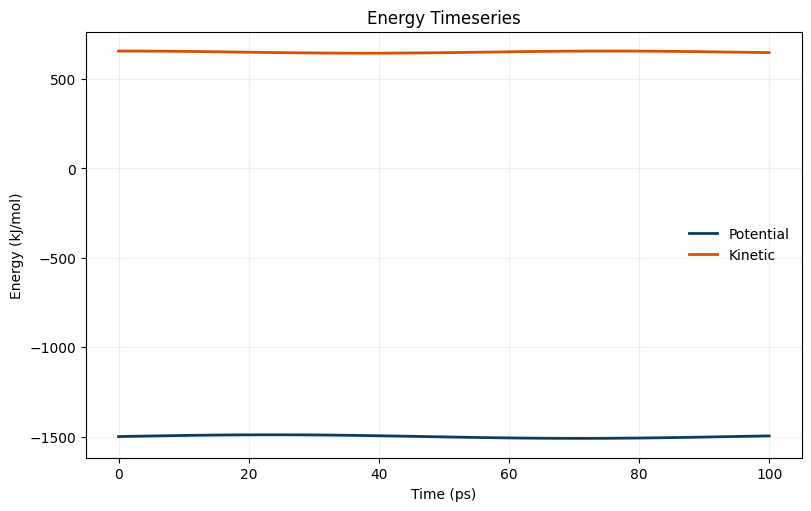

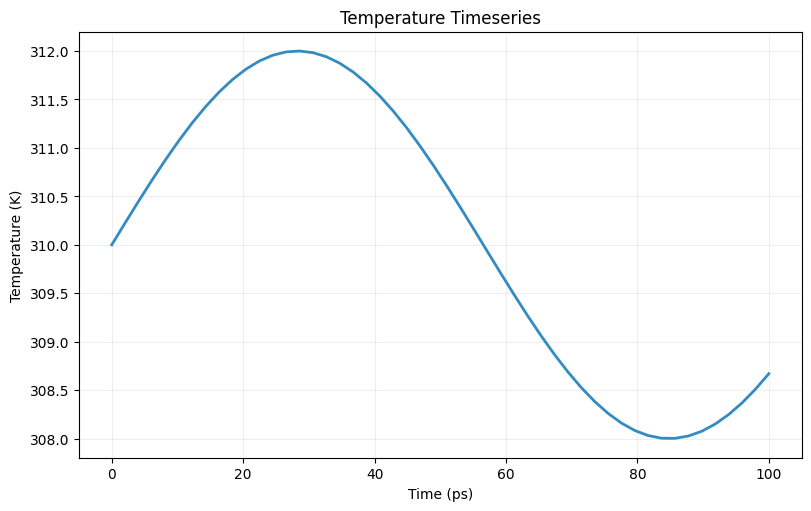

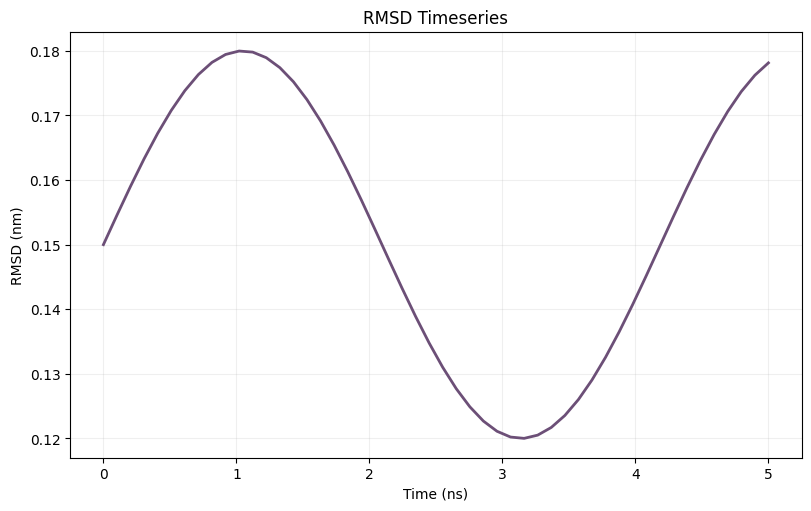

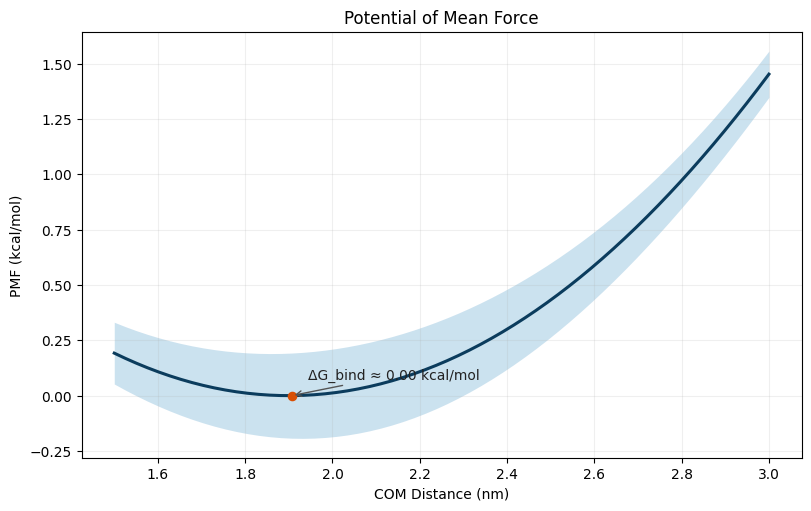

In [3]:
# Generate synthetic timeseries and render all four standard analysis plots.
time_ps = np.linspace(0.0, 100.0, 50)
potential_kj_mol = -1500.0 + 10.0 * np.sin(time_ps / 15.0)
kinetic_kj_mol = 650.0 + 6.0 * np.cos(time_ps / 12.0)
temperature_k = 310.0 + 2.0 * np.sin(time_ps / 18.0)
rmsd_time_ns = np.linspace(0.0, 5.0, 50)
rmsd_nm = 0.15 + 0.03 * np.sin(rmsd_time_ns * 1.5)
xi_bins_nm = np.linspace(1.5, 3.0, 60)
pmf_kcal_mol = 1.2 * (xi_bins_nm - 1.9) ** 2
pmf_std_kcal_mol = 0.15 + 0.05 * np.cos(xi_bins_nm * 3.0)

energy_figure = plot_energy_timeseries(time_ps, potential_kj_mol, kinetic_kj_mol)
temperature_figure = plot_temperature_timeseries(time_ps, temperature_k)
rmsd_figure = plot_rmsd_timeseries(rmsd_time_ns, rmsd_nm)
pmf_figure = plot_pmf(xi_bins_nm, pmf_kcal_mol, pmf_std_kcal_mol)
energy_figure, temperature_figure, rmsd_figure, pmf_figure

## Final Guidance

Use the widget and figure cells together. The 2D plots tell you where an event happens in time or along a reaction coordinate; the 3D viewer tells you what that event looks like structurally. That bridge from observable to mechanism is the point of the visualization layer.

In [4]:
from src.visualization.viewer_3d import render_complex
from pathlib import Path

# Load the cleaned, protonated 1BRS PDB 
pdb_path = DATA_DIR / 'pdb' / 'prepared' / '1BRS_cleaned_protonated.pdb'

view = render_complex(pdb_path)
view

3Dmol.js failed to load for some reason. Please check your browser console for error messages.